# UCI Dataset: Taiwanese Bankruptcy Prediction

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from sklearn.preprocessing import LabelEncoder
from ucimlrepo import fetch_ucirepo

from sklearn.neighbors import KernelDensity

from tqdm import tqdm

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import ld
from utils import vectorize_tensor, reconstruct_tensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    cp.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(42)
k = 5
bandwidth = 0.05
bandwidth_AE = 0.05
eps = np.asarray(1.0e-5)

### Dataset

In [3]:
class NumpyDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        """
        Args:
            features (np.ndarray): Feature matrix.
            labels (np.ndarray): Label array.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = self.features[idx]
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

# Normalize transform for UCI dataset
class Normalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

    def __call__(self, sample):
        # std is 0 for constant features, so we add a small epsilon to avoid division by zero
        return (sample - self.mean) / (self.std + eps)

# Custom transformation for adding Gaussian noise
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, sample):
        noise = torch.randn_like(sample) * self.std + self.mean
        return sample + noise

# Composite transformation to combine Normalize and AddGaussianNoise
class CompositeTransform:
    def __init__(self, transforms):
        """
        Args:
            transforms (list): List of transformations to apply in sequence.
        """
        self.transforms = transforms

    def __call__(self, sample):
        for transform in self.transforms:
            sample = transform(sample)
        return sample

In [4]:
UCI_id = 572 # https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction
test_size = 0.2

UCI_dataset = fetch_ucirepo(id=UCI_id)

X = np.array(UCI_dataset.data.features)
Y = np.array(LabelEncoder().fit_transform(UCI_dataset.data.targets))

# normalize to [0, 1]
X = (X - X.min()) / (X.max() - X.min())

# Find unique labels
unique_labels = np.unique(Y)

# Create an array of indices
indices = np.arange(len(Y))
np.random.shuffle(indices)

# Use the shuffled indices to randomly select data for training and testing
n_train = int(len(Y) * (1 - test_size))
X_train, Y_train = X[indices[:n_train]], Y[indices[:n_train]]
X_test, Y_test = X[indices[n_train:]], Y[indices[n_train:]]

X_train_class = []
Y_train_class = []
for i in unique_labels:
    X_train_class.append(X_train[np.isin(Y_train, i).flatten()])
    Y_train_class.append(Y_train[np.isin(Y_train, i).flatten()])

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

train_dataset = NumpyDataset(X_train, Y_train, transform=Normalize(mean, std))
test_dataset = NumpyDataset(X_test, Y_test, transform=Normalize(mean, std))

In [5]:
# Feature dimension
D = X_train.shape[1]
S = (5, 19)

if np.prod(S) != D:
    raise ValueError("The product of the tensor structure is not equal to the feature dimension")

new_sample_size_per_class = int(n_train * 0.2 // len(unique_labels))

# Print dataset statistics
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"New sample size: {new_sample_size_per_class * len(unique_labels)}")
print(f"Number of classes: {len(unique_labels)}")
print(f"Number of features: {D}")

Train size: 5455
Test size: 1364
New sample size: 1090
Number of classes: 2
Number of features: 95


## Pseudo-Non-Linear Data Augmentation

### Legendre Decomposition (Many-Body Approximation)

In [6]:
B_LD = ld.default_B(S, 1, cp.get_array_module(X_train[0]))
print(f"Dimension of Base Sub-Manifold: {B_LD.shape[0]}")

scaleX_class = []
theta_class = []

def LD_helper(i, class_):
    _, _, scaleX, _, theta = ld.LD(X_train_class[class_][i].reshape(*S), B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
    return (scaleX, theta)

results = Parallel(n_jobs=30)(delayed(LD_helper)(i, class_) for class_ in unique_labels for i in range(len(X_train_class[class_])))

len_class = 0
for class_ in unique_labels:
    scaleX_list = []
    theta_list = []

    for i in range(len(X_train_class[class_])):
        result = results[i + len_class]

        scaleX_list.append(result[0])
        theta_list.append(result[1])

    len_class += len(X_train_class[class_])

    scaleX_class.append(scaleX_list)
    theta_class.append(theta_list)

Dimension of Base Sub-Manifold: 23


#### Fitting and Sampling

In [7]:
sampled_theta_class = []

for class_ in unique_labels:
    reduced_theta = vectorize_tensor(np.array(theta_class[class_]), B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=new_sample_size_per_class)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (new_sample_size_per_class, *S), B_LD)

    sampled_theta_class.append(sampled_theta)

#### Construct Submanifold

In [8]:
# Construct the constrained coordinates
B_BP = ld.default_B(S, 1, cp.get_array_module(X_train[0]))
print(f"Dimension of Local Data Sub-Manifold: {D - B_BP.shape[0]}")

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_class = []

for class_ in unique_labels:
    eta_hat_list = []
    for i in range(X_train_class[class_].shape[0]):
        xp = cp.get_array_module(X_train_class[class_][i])
        P = (X_train_class[class_][i].reshape(*S) + eps) / scaleX_class[class_][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)
    eta_hat_list = cp.asarray(eta_hat_list)

    eta_hat_class.append(eta_hat_list)

Dimension of Local Data Sub-Manifold: 72


#### Backward Projection

In [9]:
def BP_helper(i, class_):
    N = ld.kNN(sampled_theta_class[class_][i], np.array(theta_class[class_]), k=k)
    avg_scale = np.mean(np.array(scaleX_class[class_])[N])
    avg_eta_hat = np.mean(eta_hat_class[class_][N], axis=0)

    _, _, P, theta = ld.BP(sampled_theta_class[class_][i], [(X_train_class[class_][j].reshape(*S) + eps) / scaleX_class[class_][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=5e-2, exit_abs=True)
    X_recons_ = P.reshape(-1)
    return (theta, X_recons_)

results = Parallel(n_jobs=30)(delayed(BP_helper)(i, class_) for i in range(new_sample_size_per_class) for class_ in unique_labels)

sampled_theta_BP_class = []
sampled_X_BP_class = []

for class_ in unique_labels:
    sampled_theta_BP = []
    sampled_X_BP = []
    for i in range(new_sample_size_per_class):
        result = results[i + new_sample_size_per_class * class_]

        sampled_theta_BP.append(result[0])
        sampled_X_BP.append(result[1])

    sampled_theta_BP_class.append(np.array(sampled_theta_BP))
    sampled_X_BP_class.append(np.array(sampled_X_BP))

Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.
Converged.

## Data Augmentation with Autoencoder

In [10]:
class Encoder(nn.Module):
    def __init__(self, input_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, z_dim)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class Decoder(nn.Module):
    def __init__(self, output_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(z_dim , hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

100%|██████████| 200/200 [02:01<00:00,  1.64it/s]


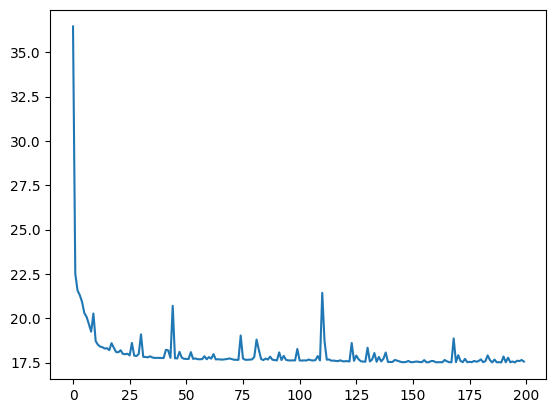

In [11]:
train_loader_original = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

enc = Encoder().to(device)
dec = Decoder().to(device)
loss_fn = nn.MSELoss()
optimizer_enc = torch.optim.Adam(enc.parameters())
optimizer_dec = torch.optim.Adam(dec.parameters())

train_loss = []
num_epochs = 200

for epoch in tqdm(range(num_epochs)):
    train_epoch_loss = 0
    for (x , _) in train_loader_original:
        x = x.to(device).float()
        x = x.flatten(1)
        latents = enc(x)
        output = dec(latents)
        loss = loss_fn(output , x)
        train_epoch_loss += loss.cpu().detach().numpy()
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
    train_loss.append(train_epoch_loss)
plt.plot(train_loss)

In [12]:
representation = None
all_labels = []

with torch.no_grad():
    for (xs , labels) in train_loader_original:
        xs = xs.to(device).float()
        xs = xs.flatten(1)
        all_labels.extend(list(labels.numpy()))
        latents = enc(xs)
        if representation is None:
            representation = latents.cpu()
        else:
            representation = torch.vstack([representation , latents.cpu()])

all_labels = np.array(all_labels)
representation = representation.numpy()

In [13]:
sampled_X_AE_class = []

for class_ in unique_labels:
    sampled_X_AE_list = []

    rep = representation[np.argwhere(all_labels == class_)].squeeze()
    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth_AE).fit(rep)

    # Sample new data from the KDE
    sampled_rep = kde.sample(n_samples=new_sample_size_per_class)
    for i in range(new_sample_size_per_class):
        pred = dec(torch.Tensor(sampled_rep[i])[None , ...].to(device)).cpu().detach().numpy()
        sampled_X_AE_list.append(pred.flatten())

    sampled_X_AE_class.append(sampled_X_AE_list)

## Mixup

In [14]:
def mixup_data(x, y, alpha=1.0, device='cuda'):
    """
    Perform mixup on a batch of data.

    Args:
        x: Input features (batch_size, feature_dim)
        y: Labels (batch_size,)
        alpha: Beta distribution parameter for mixup
        device: Device to use

    Returns:
        mixed_x: Mixed inputs
        y_a: First set of labels
        y_b: Second set of labels
        lam: Mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)

    # Generate random permutation of batch indices
    index = torch.randperm(batch_size).to(device)

    # Mix inputs: x_mixed = lam * x_i + (1 - lam) * x_j
    mixed_x = lam * x + (1 - lam) * x[index]

    # Return both labels for soft label computation
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(pred, y_a, y_b, lam, num_classes):
    """
    Compute mixup loss with soft labels.

    Soft label = lam * one_hot(y_a) + (1 - lam) * one_hot(y_b)
    Loss = CrossEntropy(pred, soft_label)

    Args:
        pred: Model predictions (logits) of shape (batch_size, num_classes)
        y_a: First set of labels (batch_size,)
        y_b: Second set of labels (batch_size,)
        lam: Mixing coefficient
        num_classes: Number of classes

    Returns:
        loss: Scalar loss value
    """
    # Convert hard labels to one-hot vectors
    batch_size = y_a.size(0)
    y_a_one_hot = torch.zeros(batch_size, num_classes, device=pred.device)
    y_b_one_hot = torch.zeros(batch_size, num_classes, device=pred.device)
    y_a_one_hot.scatter_(1, y_a.unsqueeze(1), 1)
    y_b_one_hot.scatter_(1, y_b.unsqueeze(1), 1)

    # Create soft labels: lam * y_a + (1-lam) * y_b
    soft_labels = lam * y_a_one_hot + (1 - lam) * y_b_one_hot

    # Compute cross-entropy with soft labels
    # CE = -sum(soft_labels * log_softmax(pred))
    log_probs = torch.nn.functional.log_softmax(pred, dim=1)
    loss = -torch.sum(soft_labels * log_probs) / batch_size

    return loss

def train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train model with Mixup augmentation.

    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device)

            # Apply mixup
            if alpha > 0:
                mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha, device)

                optimizer.zero_grad()
                outputs = model(mixed_images)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels_a, labels_b, lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

## Classification Performance

### Dataset Preparation

In [15]:
# Helper function to create a DataLoader for augmented datasets
def prepare_augmented_dataset(original_dataset, augmented_data, augmented_labels, transform, batch_size):
    # Create dataset from augmented data
    augmented_dataset = NumpyDataset(features=augmented_data, labels=augmented_labels, transform=transform)

    # Combine with the original dataset
    combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

    # Create a DataLoader for the combined dataset
    return DataLoader(dataset=combined_dataset, batch_size=batch_size, shuffle=True)

# Main function to prepare datasets and loaders
def create_datasets_and_loaders(batch_size=64):
    # Define transformations
    transform_standard = CompositeTransform([
        Normalize(mean, std),
        AddGaussianNoise(mean=0.0, std=std.min()/4)  # Add Gaussian noise with 1/4 of the standard deviation
    ])
    transform_none = Normalize(mean, std)

    train_standard = NumpyDataset(X_train, Y_train, transform=transform_standard)
    train_none = NumpyDataset(X_train, Y_train, transform=transform_none)

    augmented_data_PNL = []
    labels_PNL = []
    augmented_data_AE = []
    labels_AE = []

    for class_ in range(len(unique_labels)):
        for data_PNL in sampled_X_BP_class[class_]:
            augmented_data_PNL.append(data_PNL)
            labels_PNL.append(class_)

        for data_AE in sampled_X_AE_class[class_]:
            augmented_data_AE.append(data_AE)
            labels_AE.append(class_)

    augmented_data_PNL = np.array(augmented_data_PNL)
    labels_PNL = np.array(labels_PNL)
    augmented_data_AE = np.array(augmented_data_AE)
    labels_AE = np.array(labels_AE)

    mean_LD = augmented_data_PNL.mean(axis=0)
    std_LD = augmented_data_PNL.std(axis=0)
    transform_none_LD = Normalize(mean_LD, std_LD)

    mean_AE = augmented_data_AE.mean(axis=0)
    std_AE = augmented_data_AE.std(axis=0)
    transform_none_AE = Normalize(mean_AE, std_AE)

    # Combine original with augmented data
    train_loader_PNL = prepare_augmented_dataset(train_none, augmented_data_PNL, labels_PNL, transform_none_LD, batch_size)
    train_loader_AE = prepare_augmented_dataset(train_none, augmented_data_AE, labels_AE, transform_none_AE, batch_size)

    # DataLoader for the original dataset only
    train_loader_standard = DataLoader(train_standard, batch_size=batch_size, shuffle=True)
    train_loader_none = DataLoader(train_none, batch_size=batch_size, shuffle=True)

    return {
        "standard": train_loader_standard,
        "none": train_loader_none,
        "PNL_augmented": train_loader_PNL,
        "AE_augmented": train_loader_AE,
    }

loaders = create_datasets_and_loaders(batch_size=16)

# Check each DataLoader
for name, loader in loaders.items():
    print(f"{name} loader:")
    for images, labels in loader:
        print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")
        break

train_loader_standard = loaders["standard"]
train_loader_none = loaders["none"]
train_loader_PNL = loaders["PNL_augmented"]
train_loader_AE = loaders["AE_augmented"]

standard loader:
Images shape: torch.Size([16, 95]), Labels shape: torch.Size([16])
none loader:
Images shape: torch.Size([16, 95]), Labels shape: torch.Size([16])
PNL_augmented loader:
Images shape: torch.Size([16, 95]), Labels shape: torch.Size([16])
AE_augmented loader:
Images shape: torch.Size([16, 95]), Labels shape: torch.Size([16])


### MLP Model

In [16]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=8, num_classes=len(unique_labels)):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, num_classes)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, self.input_size)  # Flatten the input
        x = self.activation(self.hidden_layer(x))  # Apply hidden layer + ReLU
        x = self.output_layer(x)  # Apply output layer
        return x

# Training Function
def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs, device='cuda'):
    train_loss = []
    model.to(device)
    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device).float(), labels.to(device)
            outputs = model(features)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def bootstrapping(train_loader, test_dataset, num_epochs=10, learning_rate=1e-1, n_bootstrap=20, device='cuda'):
    """
    Train the Logistic Regression model on the training dataset, and evaluate it using bootstrapping on the test dataset.

    Args:
        train_loader: DataLoader for training data.
        test_dataset: Dataset object for the test data.
        num_epochs: Number of epochs for training.
        learning_rate: Learning rate for the optimizer.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        Prints the mean accuracy and 95% confidence interval after bootstrapping.
    """
    # Initialize the model, loss, and optimizer
    model = MLP(input_size=D ,num_classes=len(unique_labels)).to(device)
    criterion = nn.CrossEntropyLoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # Decay LR every 30 epochs

    # Train the model
    train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

    # Perform bootstrapping
    accuracies = []

    num_test_samples = len(test_dataset) // 2
    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

def bootstrapping_mixup(train_loader, test_dataset, num_epochs=10, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train MLP with Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, and optimizer
    model = MLP(input_size=D, num_classes=len(unique_labels)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Mixup
    train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler,
                          num_epochs=num_epochs, alpha=alpha, num_classes=len(unique_labels), device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

### Manifold Mixup

In [17]:

class MLP_ManifoldMixup(nn.Module):
    """
    MLP with support for Manifold Mixup.
    Can apply mixup at intermediate hidden layers.
    """
    def __init__(self, input_size, hidden_size=8, num_classes=len(unique_labels)):
        super(MLP_ManifoldMixup, self).__init__()
        self.input_size = input_size
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, num_classes)
        self.activation = nn.ReLU()

    def forward(self, x, mixup_layer=None, mixup_index=None, mixup_lam=None):
        """
        Forward pass with optional manifold mixup.

        Args:
            x: Input features
            mixup_layer: Layer at which to apply mixup (None, 0, or 1)
                        None: no mixup
                        0: mixup at input layer
                        1: mixup at hidden layer
            mixup_index: Indices for mixing samples
            mixup_lam: Mixing coefficient

        Returns:
            Output logits
        """
        x = x.view(-1, self.input_size)  # Flatten the input

        # Apply mixup at input layer (same as regular mixup)
        if mixup_layer == 0 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        # Hidden layer
        x = self.hidden_layer(x)
        x = self.activation(x)

        # Apply mixup at hidden layer (this is the key for manifold mixup)
        if mixup_layer == 1 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        # Output layer
        x = self.output_layer(x)

        return x

def train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train model with Manifold Mixup augmentation.

    Manifold mixup randomly selects a layer and applies mixup at that layer's representation.

    Args:
        model: MLP_ManifoldMixup model
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    # Number of possible mixup layers (0=input, 1=hidden)
    num_layers = 2

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device)

            # Apply manifold mixup
            if alpha > 0:
                # Randomly select which layer to apply mixup
                mixup_layer = np.random.randint(0, num_layers)

                # Sample mixing coefficient
                lam = np.random.beta(alpha, alpha)

                # Generate random permutation
                batch_size = images.size(0)
                index = torch.randperm(batch_size).to(device)

                optimizer.zero_grad()

                # Forward pass with manifold mixup
                outputs = model(images, mixup_layer=mixup_layer, mixup_index=index, mixup_lam=lam)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels, labels[index], lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def bootstrapping_manifold_mixup(train_loader, test_dataset, num_epochs=10, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train MLP with Manifold Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Manifold Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, and optimizer
    model = MLP_ManifoldMixup(input_size=D, num_classes=len(unique_labels)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Manifold Mixup
    train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler,
                                   num_epochs=num_epochs, alpha=alpha, num_classes=len(unique_labels), device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        # Use model without mixup for evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in bootstrap_loader:
                features, labels = features.to(device).float(), labels.to(device)
                outputs = model(features)  # No mixup during evaluation
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

print("Evaluation functions for Mixup and Manifold Mixup defined successfully")

Evaluation functions for Mixup and Manifold Mixup defined successfully


### Baseline Evaluations

  2%|▏         | 2/100 [00:01<01:33,  1.04it/s]

100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


Mean accuracy: 96.54%
Standard deviation: 0.56


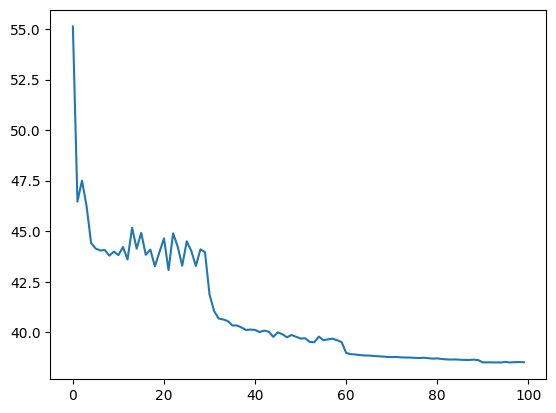

In [18]:
bootstrapping(train_loader_none, test_dataset, num_epochs=100, learning_rate=1e-1, device=device)

100%|██████████| 100/100 [01:47<00:00,  1.08s/it]


Mean accuracy: 96.17%
Standard deviation: 0.57


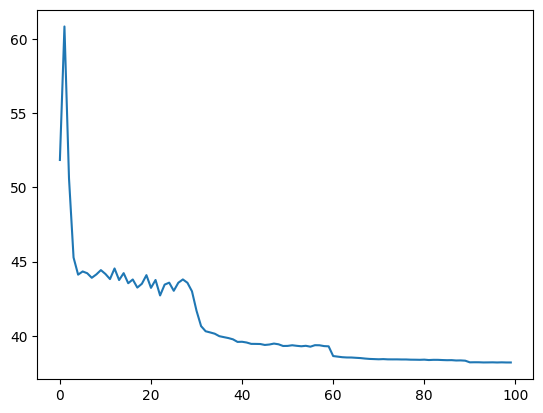

In [19]:
bootstrapping(train_loader_standard, test_dataset, num_epochs=100, learning_rate=0.1, device=device)

100%|██████████| 100/100 [01:45<00:00,  1.05s/it]


Mean accuracy: 96.53%
Standard deviation: 0.47


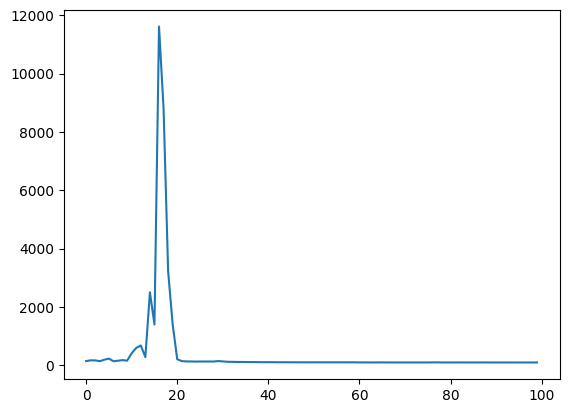

In [20]:
bootstrapping(train_loader_PNL, test_dataset, num_epochs=100, learning_rate=0.1, device=device)

100%|██████████| 100/100 [01:51<00:00,  1.11s/it]


Mean accuracy: 95.92%
Standard deviation: 0.62


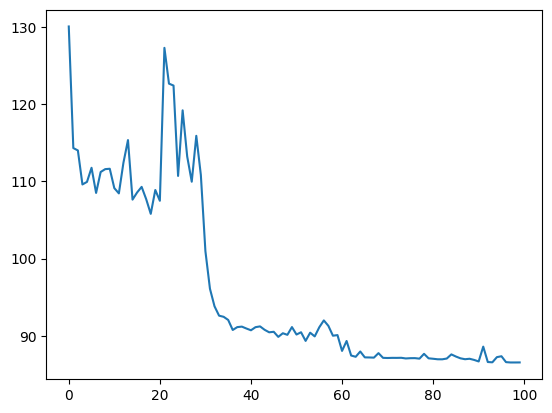

In [21]:
bootstrapping(train_loader_AE, test_dataset, num_epochs=100, learning_rate=0.1, device=device)

100%|██████████| 100/100 [01:50<00:00,  1.11s/it]


Mean accuracy: 96.55%
Standard deviation: 0.68


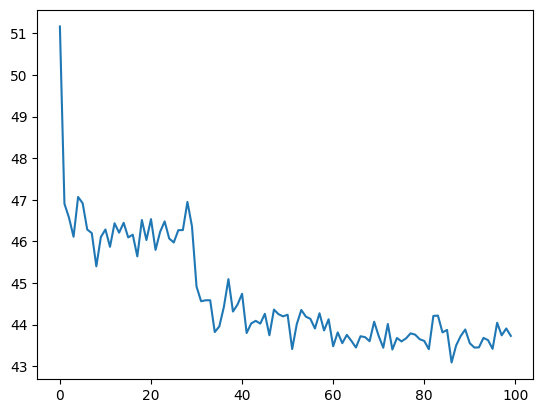

In [22]:
bootstrapping_mixup(train_loader_none, test_dataset, num_epochs=100, learning_rate=0.1, alpha=1.0, device=device)

100%|██████████| 100/100 [01:54<00:00,  1.14s/it]


Mean accuracy: 96.44%
Standard deviation: 0.53


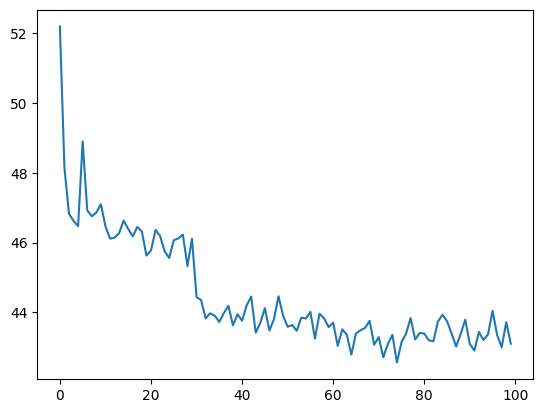

In [23]:
bootstrapping_manifold_mixup(train_loader_none, test_dataset, num_epochs=100, learning_rate=0.1, alpha=1.0, device=device)